### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Connect to SQLite Database

In [ ]:
conn = sqlite3.connect("/content/drive/MyDrive/datasets/database.sqlite")

### Check Available Tables

In [ ]:
query = "SELECT name FROM sqlite_master WHERE type='table';"

tables = pd.read_sql(query, conn)

tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


### Countries Check

In [ ]:
country = pd.read_sql("SELECT * FROM Country;", conn)

country

,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy
5,13274,Netherlands
6,15722,Poland
7,17642,Portugal
8,19694,Scotland
9,21518,Spain


### Leagues Check

In [ ]:
league = pd.read_sql("SELECT * FROM League;", conn)

league

,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A
5,13274,13274,Netherlands Eredivisie
6,15722,15722,Poland Ekstraklasa
7,17642,17642,Portugal Liga ZON Sagres
8,19694,19694,Scotland Premier League
9,21518,21518,Spain LIGA BBVA


In [ ]:
league[league['name'].str.contains('Premier', case=False)]

,id,country_id,name
1,1729,1729,England Premier League
8,19694,19694,Scotland Premier League


In [ ]:
match = pd.read_sql("SELECT * FROM Match LIMIT 5;", conn)

match.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [ ]:
match.columns

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='object', length=115)

### Extract Only EPL Matches

In [ ]:
epl_matches = pd.read_sql("""
SELECT *
FROM Match
WHERE league_id = 1729
""", conn)

epl_matches.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1729,1729,1729,2008/2009,1,2008-08-17 00:00:00,489042,10260,10261,1,...,10.00,1.28,5.5,12.00,1.30,4.75,10.0,1.29,4.50,11.00
1,1730,1729,1729,2008/2009,1,2008-08-16 00:00:00,489043,9825,8659,1,...,12.00,1.25,6.0,13.00,1.22,5.50,13.0,1.22,5.00,13.00
2,1731,1729,1729,2008/2009,1,2008-08-16 00:00:00,489044,8472,8650,0,...,1.73,5.50,3.8,1.65,5.00,3.40,1.7,4.50,3.40,1.73
3,1732,1729,1729,2008/2009,1,2008-08-16 00:00:00,489045,8654,8528,2,...,3.75,1.90,3.5,4.35,1.91,3.25,4.0,1.91,3.25,3.80
4,1733,1729,1729,2008/2009,1,2008-08-17 00:00:00,489046,10252,8456,4,...,3.75,1.90,3.5,4.35,1.91,3.25,4.0,1.91,3.30,3.75


In [ ]:
print("Shape of EPL Dataset:", epl_matches.shape)

Shape of EPL Dataset: (3040, 115)


### Save CSV

In [ ]:
epl_matches.to_csv("epl_matches.csv", index=False)

print("EPL dataset saved successfully!")

EPL dataset saved successfully!


In [ ]:
df = pd.read_csv("epl_matches.csv")

df.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1729,1729,1729,2008/2009,1,2008-08-17 00:00:00,489042,10260,10261,1,...,10.00,1.28,5.5,12.00,1.30,4.75,10.0,1.29,4.50,11.00
1,1730,1729,1729,2008/2009,1,2008-08-16 00:00:00,489043,9825,8659,1,...,12.00,1.25,6.0,13.00,1.22,5.50,13.0,1.22,5.00,13.00
2,1731,1729,1729,2008/2009,1,2008-08-16 00:00:00,489044,8472,8650,0,...,1.73,5.50,3.8,1.65,5.00,3.40,1.7,4.50,3.40,1.73
3,1732,1729,1729,2008/2009,1,2008-08-16 00:00:00,489045,8654,8528,2,...,3.75,1.90,3.5,4.35,1.91,3.25,4.0,1.91,3.25,3.80
4,1733,1729,1729,2008/2009,1,2008-08-17 00:00:00,489046,10252,8456,4,...,3.75,1.90,3.5,4.35,1.91,3.25,4.0,1.91,3.30,3.75


In [ ]:
print("Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

Shape: (3040, 115)

Columns:

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='object', length=115)

Data Types:

id              int64
country_id      int64
league_id       int64
season         object
stage           int64
               ...   
GBD           float64
GBA           float64
BSH           float64
BSD           float64
BSA           float64
Length: 115, dtype: object


In [ ]:
df.describe(include='all')

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
count,3040.000000,3040.0,3040.0,3040,3040.00000,3040,3.040000e+03,3040.00000,3040.00000,3040.000000,...,2320.000000,3040.000000,3040.000000,3040.000000,1899.000000,1899.000000,1899.000000,1900.000000,1900.000000,1900.000000
unique,NaN,NaN,NaN,8,NaN,804,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,2008/2009,NaN,2012-05-13 00:00:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,380,NaN,10,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3248.500000,1729.0,1729.0,NaN,19.50000,NaN,1.178767e+06,9142.27500,9142.27500,1.550987,...,4.859233,2.712200,3.955470,4.956706,2.606840,3.761980,4.566435,2.625553,3.773584,4.790621
std,877.716735,0.0,0.0,NaN,10.96766,NaN,4.909627e+05,753.08936,753.08936,1.311615,...,3.826951,1.692002,1.009081,3.984338,1.586001,0.842088,3.301710,1.655792,0.837965,3.786069
min,1729.000000,1729.0,1729.0,NaN,1.00000,NaN,4.890420e+05,8191.00000,8191.00000,0.000000,...,1.250000,1.090000,2.500000,1.220000,1.100000,3.000000,1.250000,1.100000,3.000000,1.220000
25%,2488.750000,1729.0,1729.0,NaN,10.00000,NaN,7.946915e+05,8528.00000,8528.00000,1.000000,...,2.500000,1.670000,3.300000,2.500000,1.650000,3.250000,2.450000,1.620000,3.250000,2.500000
50%,3248.500000,1729.0,1729.0,NaN,19.50000,NaN,1.127220e+06,8659.00000,8659.00000,1.000000,...,3.500000,2.200000,3.600000,3.600000,2.100000,3.400000,3.400000,2.100000,3.400000,3.400000
75%,4008.250000,1729.0,1729.0,NaN,29.00000,NaN,1.537336e+06,9879.00000,9879.00000,2.000000,...,5.500000,3.000000,4.100000,5.500000,2.800000,3.900000,5.250000,2.800000,3.900000,5.500000


### Missing Values

In [ ]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
PSA,1521
PSH,1521
PSD,1521
GBD,1141
GBA,1141
GBH,1141
BSA,1140
BSD,1140
BSH,1140
SJH,720


### Duplicate Values

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Check Target Columns

In [ ]:
df[['home_team_goal','away_team_goal']].describe()

,home_team_goal,away_team_goal
count,3040.000000,3040.000000
mean,1.550987,1.159539
std,1.311615,1.144629
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,6.000000


### Data Types Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Columns: 115 entries, id to BSA
dtypes: float64(46), int64(59), object(10)
memory usage: 2.7+ MB


### Memory Usage

In [ ]:
df.memory_usage(deep=True)

,0
Index,132
id,24320
country_id,24320
league_id,24320
season,176320
...,...
GBD,24320
GBA,24320
BSH,24320
BSD,24320


In [ ]:
df.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1729,1729,1729,2008/2009,1,2008-08-17 00:00:00,489042,10260,10261,1,...,10.00,1.28,5.5,12.00,1.30,4.75,10.0,1.29,4.50,11.00
1,1730,1729,1729,2008/2009,1,2008-08-16 00:00:00,489043,9825,8659,1,...,12.00,1.25,6.0,13.00,1.22,5.50,13.0,1.22,5.00,13.00
2,1731,1729,1729,2008/2009,1,2008-08-16 00:00:00,489044,8472,8650,0,...,1.73,5.50,3.8,1.65,5.00,3.40,1.7,4.50,3.40,1.73
3,1732,1729,1729,2008/2009,1,2008-08-16 00:00:00,489045,8654,8528,2,...,3.75,1.90,3.5,4.35,1.91,3.25,4.0,1.91,3.25,3.80
4,1733,1729,1729,2008/2009,1,2008-08-17 00:00:00,489046,10252,8456,4,...,3.75,1.90,3.5,4.35,1.91,3.25,4.0,1.91,3.30,3.75


### Match Result Distribution

In [ ]:
df['result'] = df.apply(
    lambda x: 'Home Win' if x['home_team_goal'] > x['away_team_goal']
    else ('Away Win' if x['home_team_goal'] < x['away_team_goal']
    else 'Draw'),
    axis=1
)

df[['home_team_goal','away_team_goal','result']].head()

,home_team_goal,away_team_goal,result
0,1,1,Draw
1,1,0,Home Win
2,0,1,Away Win
3,2,1,Home Win
4,4,2,Home Win


Home wins are more common than away wins.
Draws occur less frequently.
This indicates a home advantage in the English Premier League.

### Count Plot

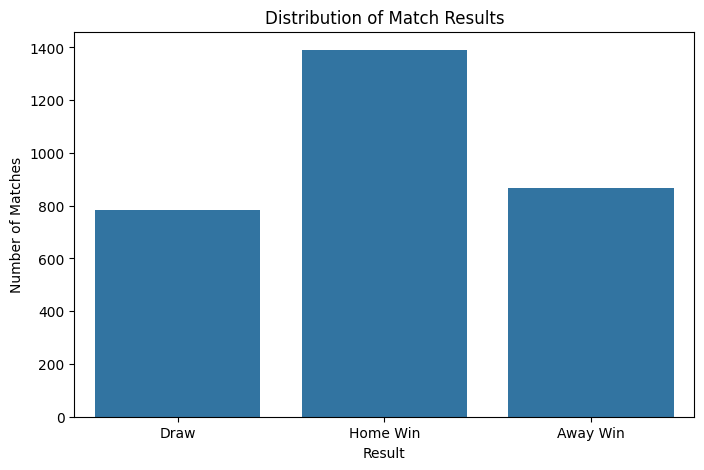

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='result', data=df)

plt.title("Distribution of Match Results")

plt.xlabel("Result")

plt.ylabel("Number of Matches")

plt.show()

### Home Goals Histogram

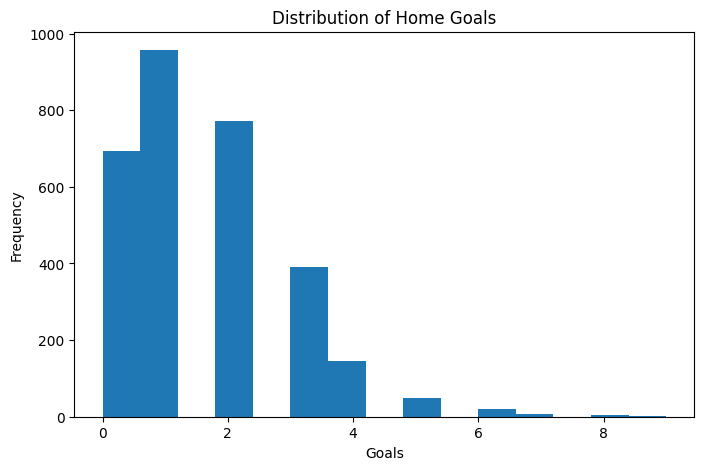

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['home_team_goal'], bins=15)

plt.title("Distribution of Home Goals")

plt.xlabel("Goals")

plt.ylabel("Frequency")

plt.show()

Most home teams score 1–2 goals per match.
Matches with 5 or more home goals are rare.
The distribution is right-skewed because a few matches have very high scores.

### Away Goals Histogram

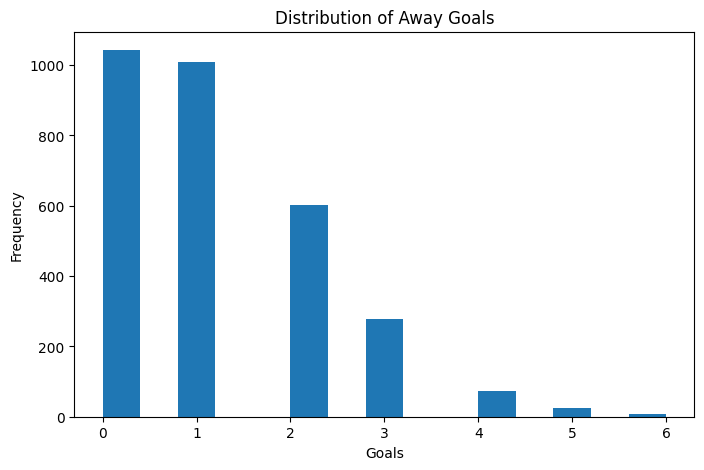

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['away_team_goal'], bins=15)

plt.title("Distribution of Away Goals")

plt.xlabel("Goals")

plt.ylabel("Frequency")

plt.show()

Most away teams score 0–2 goals.
High-scoring away matches are uncommon.
The distribution is also right-skewed.

### Boxplot

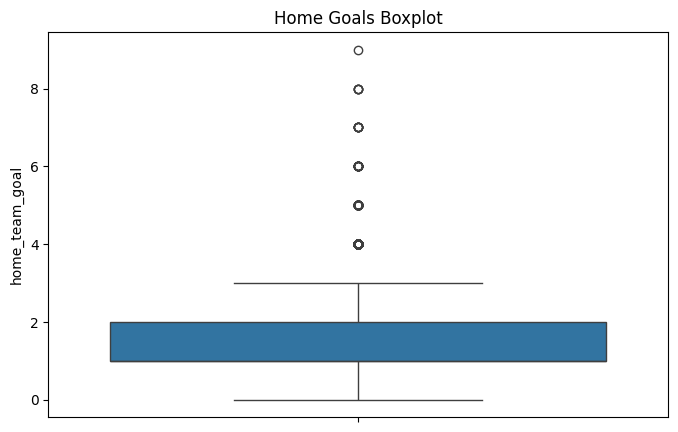

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['home_team_goal'])

plt.title("Home Goals Boxplot")

plt.show()

Most home goal values lie in a small range.
A few matches have unusually high goal counts, which appear as outliers.

### Away Goals Boxplot

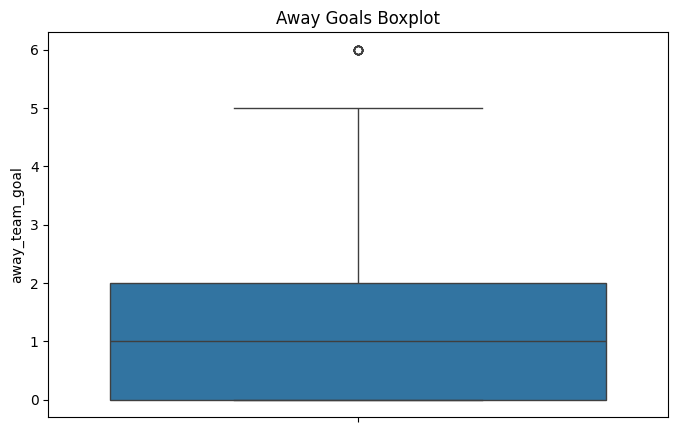

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['away_team_goal'])

plt.title("Away Goals Boxplot")

plt.show()

Away goals show a similar pattern with some outliers.
Most away teams score fewer goals compared to home teams.

### Pie Chart

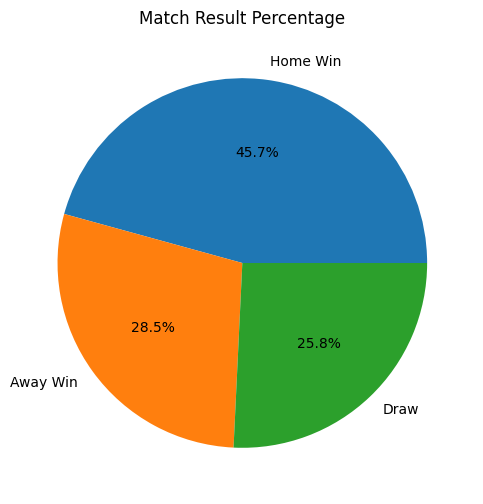

In [ ]:
result_counts = df['result'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(result_counts,
        labels=result_counts.index,
        autopct='%1.1f%%')

plt.title("Match Result Percentage")

plt.show()

Home wins occupy the largest share.
Draws and away wins make up the remaining portion.
This further supports the presence of home advantage.

### Season-wise Matches

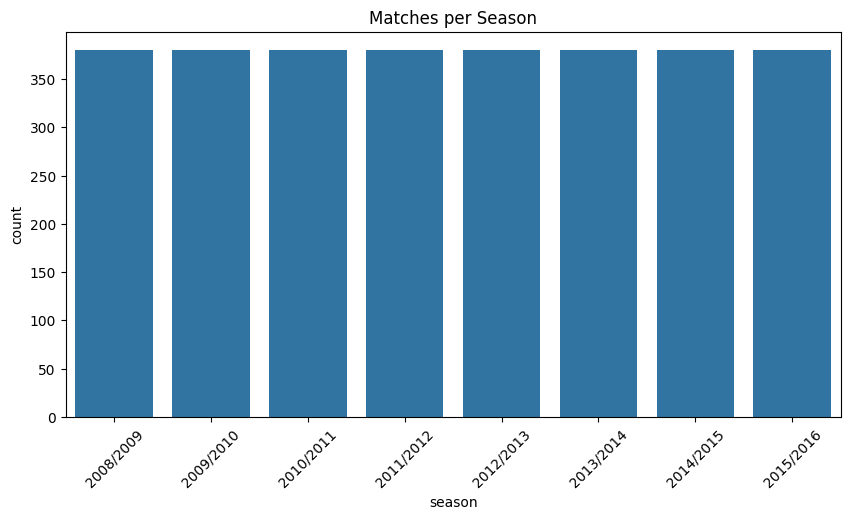

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x='season', data=df)

plt.xticks(rotation=45)

plt.title("Matches per Season")

plt.show()

Each EPL season contains approximately the same number of matches (around 380).
The dataset is balanced across seasons.

### Correlation Heatmap

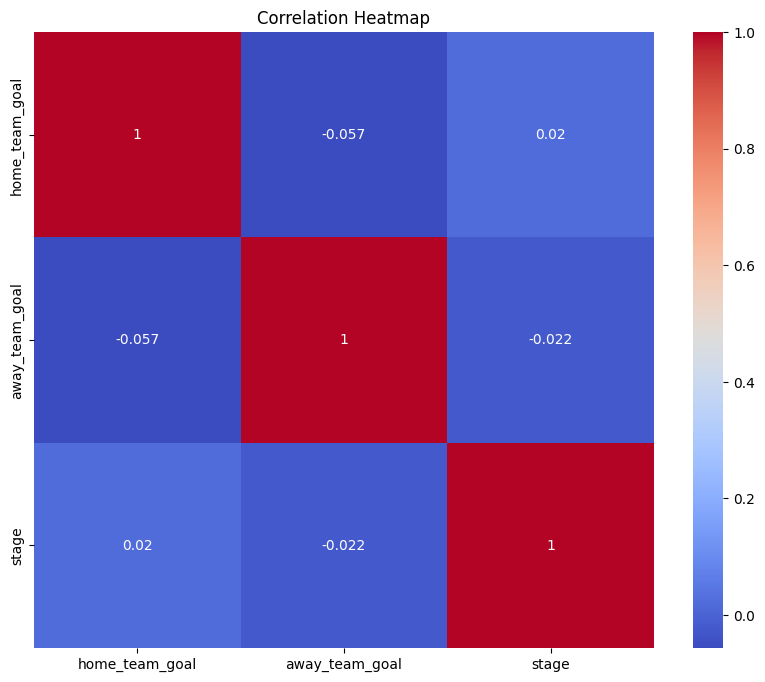

In [ ]:
plt.figure(figsize=(10,8))

corr = df[['home_team_goal',
           'away_team_goal',
           'stage']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Scatter Plot

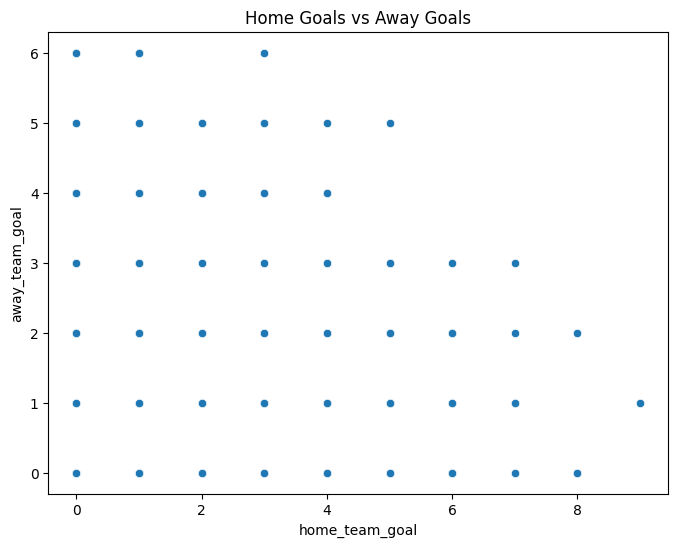

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='home_team_goal',
    y='away_team_goal',
    data=df
)

plt.title("Home Goals vs Away Goals")
plt.show()

### Goals Per Season

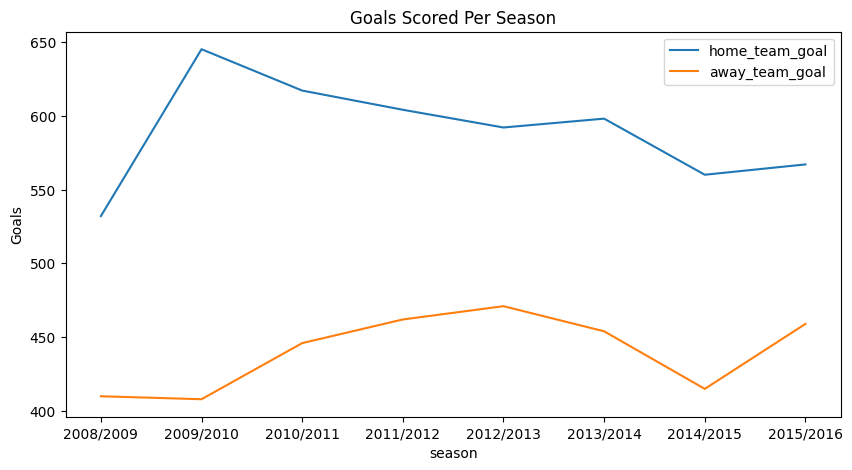

In [ ]:
season_goals = df.groupby('season')[['home_team_goal','away_team_goal']].sum()

season_goals.plot(figsize=(10,5))

plt.title("Goals Scored Per Season")
plt.ylabel("Goals")

plt.show()

### Total Goals Distribution

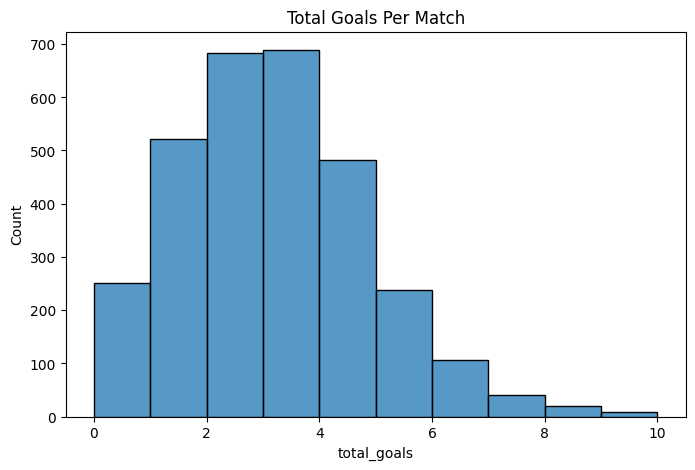

In [ ]:
df['total_goals'] = df['home_team_goal'] + df['away_team_goal']

plt.figure(figsize=(8,5))

sns.histplot(df['total_goals'], bins=10)

plt.title("Total Goals Per Match")

plt.show()

In [ ]:
team = pd.read_sql("SELECT team_api_id, team_long_name FROM Team;", conn)

team.head()

,team_api_id,team_long_name
0,9987,KRC Genk
1,9993,Beerschot AC
2,10000,SV Zulte-Waregem
3,9994,Sporting Lokeren
4,9984,KSV Cercle Brugge


### home team merge

In [ ]:
df = df.merge(
    team,
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
)

df.rename(columns={'team_long_name':'home_team'}, inplace=True)

df.drop('team_api_id', axis=1, inplace=True)

### Away team merge

In [ ]:
df = df.merge(
    team,
    left_on='away_team_api_id',
    right_on='team_api_id',
    how='left'
)

df.rename(columns={'team_long_name':'away_team'}, inplace=True)

df.drop('team_api_id', axis=1, inplace=True)

In [ ]:
df[['home_team','away_team','home_team_goal','away_team_goal']].head()

,home_team,away_team,home_team_goal,away_team_goal
0,Manchester United,Newcastle United,1,1
1,Arsenal,West Bromwich Albion,1,0
2,Sunderland,Liverpool,0,1
3,West Ham United,Wigan Athletic,2,1
4,Aston Villa,Manchester City,4,2


### Top 10 Highest Scoring Home Teams

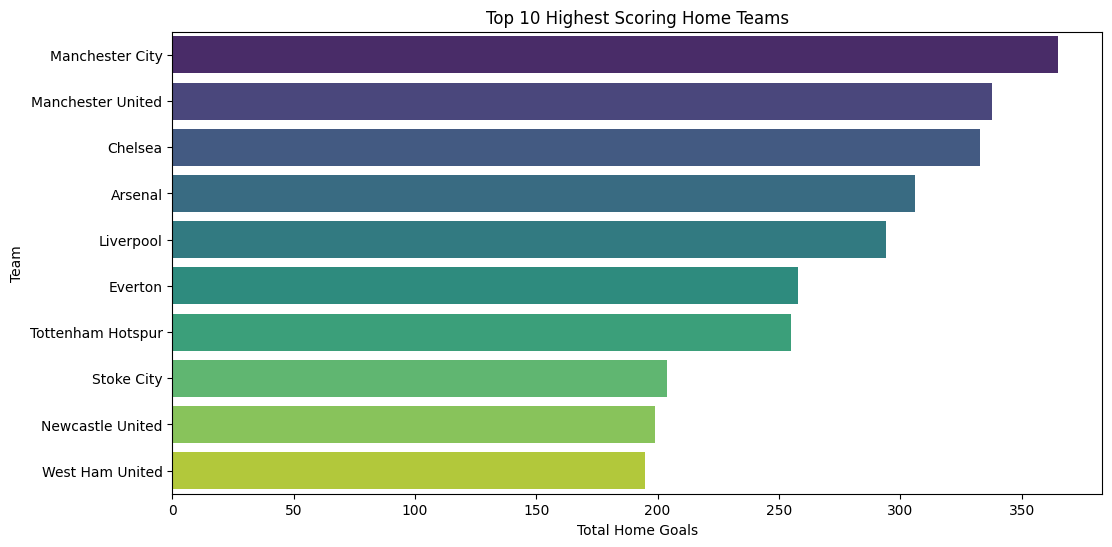

In [ ]:
home_goals = (
    df.groupby('home_team')['home_team_goal']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=home_goals.values,
    y=home_goals.index,
    palette='viridis'
)

plt.title("Top 10 Highest Scoring Home Teams")
plt.xlabel("Total Home Goals")
plt.ylabel("Team")

plt.show()

Top clubs like Manchester United, Arsenal, Chelsea, Liverpool generally score the highest number of home goals.
Strong teams perform better at home due to home advantage.

### Top 10 Highest Scoring Away Teams

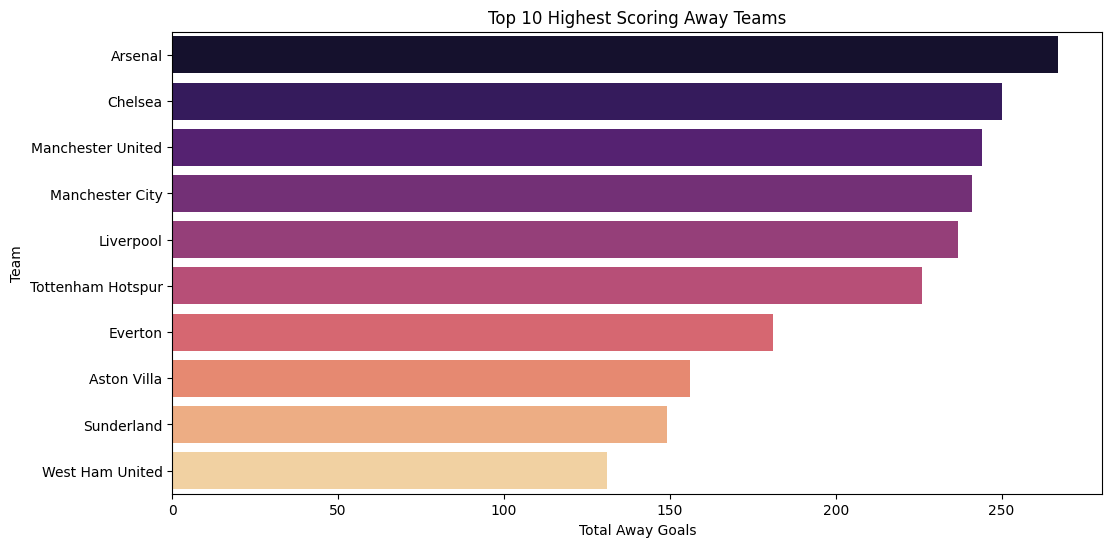

In [ ]:
away_goals = (
    df.groupby('away_team')['away_team_goal']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=away_goals.values,
    y=away_goals.index,
    palette='magma'
)

plt.title("Top 10 Highest Scoring Away Teams")
plt.xlabel("Total Away Goals")
plt.ylabel("Team")

plt.show()

### Top 10 Teams by Total Goals

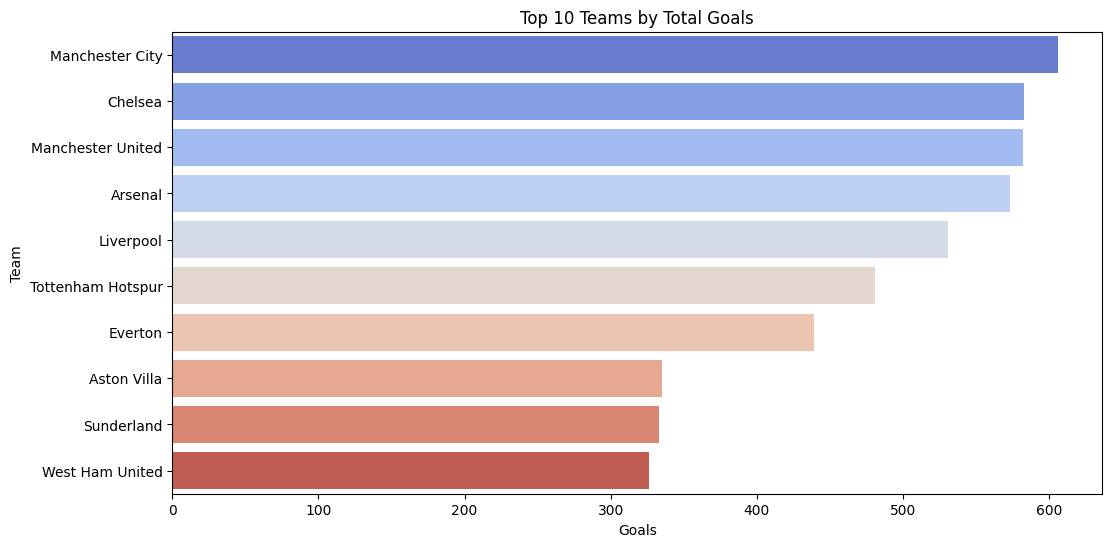

In [ ]:
df['total_goals'] = df['home_team_goal'] + df['away_team_goal']

home_total = df.groupby('home_team')['home_team_goal'].sum()
away_total = df.groupby('away_team')['away_team_goal'].sum()

total = home_total.add(away_total, fill_value=0)

top10 = total.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette='coolwarm'
)

plt.title("Top 10 Teams by Total Goals")
plt.xlabel("Goals")
plt.ylabel("Team")

plt.show()

### Average Goals Per Season

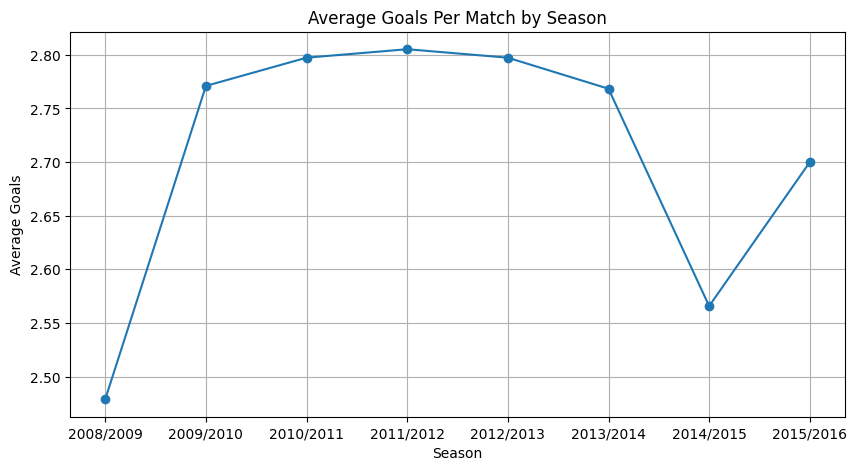

In [ ]:
season_avg = df.groupby('season')['total_goals'].mean()

plt.figure(figsize=(10,5))

season_avg.plot(marker='o')

plt.title("Average Goals Per Match by Season")
plt.xlabel("Season")
plt.ylabel("Average Goals")

plt.grid(True)

plt.show()

### Home vs Away Goals

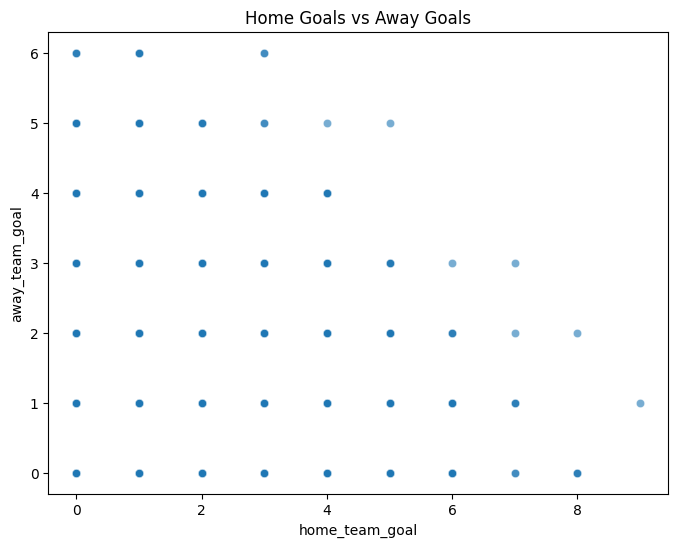

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='home_team_goal',
    y='away_team_goal',
    alpha=0.6
)

plt.title("Home Goals vs Away Goals")

plt.show()

# Data Cleaning

#### Check Missing Values

In [ ]:
# Missing values in each column
missing_values = df.isnull().sum()

# Display only columns with missing values
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

,0
PSA,1521
PSH,1521
PSD,1521
GBD,1141
GBA,1141
GBH,1141
BSA,1140
BSD,1140
BSH,1140
SJH,720


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_percentage

,0
PSA,50.032895
PSH,50.032895
PSD,50.032895
GBD,37.532895
GBA,37.532895
GBH,37.532895
BSA,37.500000
BSD,37.500000
BSH,37.500000
SJH,23.684211


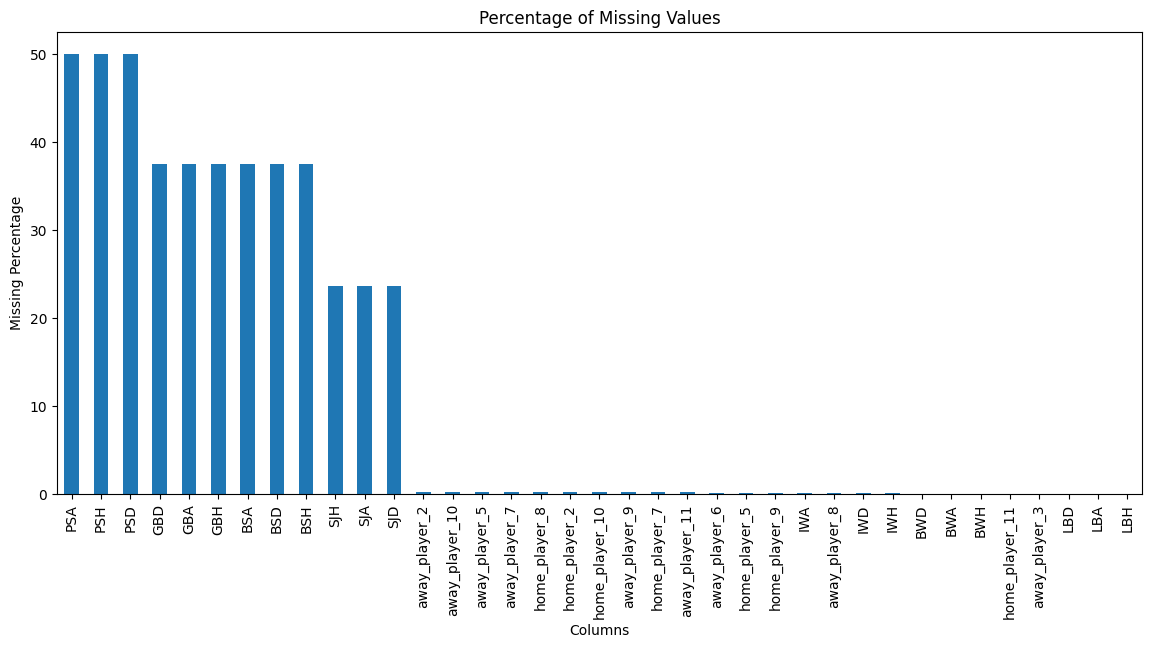

In [ ]:
plt.figure(figsize=(14,6))

missing_percentage.plot(kind='bar')

plt.title("Percentage of Missing Values")

plt.xlabel("Columns")

plt.ylabel("Missing Percentage")

plt.xticks(rotation=90)

plt.show()

Betting odds columns have the highest missing values, while player-related columns contain very few missing values.

#### Remove Unnecessary Columns

In [ ]:
df.drop(
    columns=[
        'id',
        'country_id',
        'league_id',
        'match_api_id'
    ],
    inplace=True
)

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['date'].head()

,date
0,2008-08-17
1,2008-08-16
2,2008-08-16
3,2008-08-16
4,2008-08-17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Columns: 115 entries, season to away_team
dtypes: datetime64[ns](1), float64(46), int64(56), object(12)
memory usage: 2.7+ MB


#### Duplicate Check

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
print(df.shape)

(3040, 115)


#Feature Engineering

#### Goal Difference & Total Goals

In [ ]:
df['goal_difference'] = df['home_team_goal'] - df['away_team_goal']
df['total_goals'] = df['home_team_goal'] + df['away_team_goal']

#### Match Result

In [ ]:
df['match_result'] = df.apply(
    lambda x: 'Home Win'
    if x['home_team_goal'] > x['away_team_goal']
    else (
        'Away Win'
        if x['home_team_goal'] < x['away_team_goal']
        else 'Draw'
    ),
    axis=1
)

#### Check New Columns

In [ ]:
df[['home_team',
    'away_team',
    'home_team_goal',
    'away_team_goal',
    'goal_difference',
    'total_goals',
    'match_result']].head()

,home_team,away_team,home_team_goal,away_team_goal,goal_difference,total_goals,match_result
0,Manchester United,Newcastle United,1,1,0,2,Draw
1,Arsenal,West Bromwich Albion,1,0,1,1,Home Win
2,Sunderland,Liverpool,0,1,-1,1,Away Win
3,West Ham United,Wigan Athletic,2,1,1,3,Home Win
4,Aston Villa,Manchester City,4,2,2,6,Home Win


#Feature Selection

#### Check Columns

In [ ]:
print(df.columns.tolist())

['season', 'stage', 'date', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'home_player_X1', 'home_player_X2', 'home_player_X3', 'home_player_X4', 'home_player_X5', 'home_player_X6', 'home_player_X7', 'home_player_X8', 'home_player_X9', 'home_player_X10', 'home_player_X11', 'away_player_X1', 'away_player_X2', 'away_player_X3', 'away_player_X4', 'away_player_X5', 'away_player_X6', 'away_player_X7', 'away_player_X8', 'away_player_X9', 'away_player_X10', 'away_player_X11', 'home_player_Y1', 'home_player_Y2', 'home_player_Y3', 'home_player_Y4', 'home_player_Y5', 'home_player_Y6', 'home_player_Y7', 'home_player_Y8', 'home_player_Y9', 'home_player_Y10', 'home_player_Y11', 'away_player_Y1', 'away_player_Y2', 'away_player_Y3', 'away_player_Y4', 'away_player_Y5', 'away_player_Y6', 'away_player_Y7', 'away_player_Y8', 'away_player_Y9', 'away_player_Y10', 'away_player_Y11', 'home_player_1', 'home_player_2', 'home_player_3', 'home_player_4', 'home_player_5', 'home_playe

#### Decide Features

In [ ]:
features = [
    'season',
    'stage',
    'date',
    'home_team',
    'away_team'
]

#### Targets

In [ ]:
target_home = 'home_team_goal'
target_away = 'away_team_goal'

#### Create New DataFrame

In [ ]:
model_df = df[
    [
        'season',
        'stage',
        'date',
        'home_team',
        'away_team',
        'home_team_goal',
        'away_team_goal'
    ]
]

model_df.head()

,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
0,2008/2009,1,2008-08-17,Manchester United,Newcastle United,1,1
1,2008/2009,1,2008-08-16,Arsenal,West Bromwich Albion,1,0
2,2008/2009,1,2008-08-16,Sunderland,Liverpool,0,1
3,2008/2009,1,2008-08-16,West Ham United,Wigan Athletic,2,1
4,2008/2009,1,2008-08-17,Aston Villa,Manchester City,4,2


In [ ]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   season          3040 non-null   object        
 1   stage           3040 non-null   int64         
 2   date            3040 non-null   datetime64[ns]
 3   home_team       3040 non-null   object        
 4   away_team       3040 non-null   object        
 5   home_team_goal  3040 non-null   int64         
 6   away_team_goal  3040 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 166.4+ KB


#Data Preprocessing

#### Check Missing Values in Model Dataset

In [ ]:
model_df.isnull().sum()

,0
season,0
stage,0
date,0
home_team,0
away_team,0
home_team_goal,0
away_team_goal,0


#### Convert Date into Useful Features

In [ ]:
model_df['date'] = pd.to_datetime(model_df['date'])

model_df['year'] = model_df['date'].dt.year
model_df['month'] = model_df['date'].dt.month
model_df['day'] = model_df['date'].dt.day

model_df.head()

,season,stage,date,home_team,away_team,home_team_goal,away_team_goal,year,month,day
0,2008/2009,1,2008-08-17,Manchester United,Newcastle United,1,1,2008,8,17
1,2008/2009,1,2008-08-16,Arsenal,West Bromwich Albion,1,0,2008,8,16
2,2008/2009,1,2008-08-16,Sunderland,Liverpool,0,1,2008,8,16
3,2008/2009,1,2008-08-16,West Ham United,Wigan Athletic,2,1,2008,8,16
4,2008/2009,1,2008-08-17,Aston Villa,Manchester City,4,2,2008,8,17


#### Remove original date

In [ ]:
model_df.drop('date', axis=1, inplace=True)

#### Encode Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder
home_encoder = LabelEncoder()
away_encoder = LabelEncoder()
season_encoder = LabelEncoder()

In [ ]:
model_df['home_team'] = home_encoder.fit_transform(model_df['home_team'])

model_df['away_team'] = away_encoder.fit_transform(model_df['away_team'])

model_df['season'] = season_encoder.fit_transform(model_df['season'])

In [ ]:
model_df.head()

,season,stage,home_team,away_team,home_team_goal,away_team_goal,year,month,day
0,0,1,17,19,1,1,2008,8,17
1,0,1,0,30,1,0,2008,8,16
2,0,1,26,15,0,1,2008,8,16
3,0,1,31,32,2,1,2008,8,16
4,0,1,1,16,4,2,2008,8,17


#### Separate Features and Targets

In [ ]:
X = model_df.drop(
    columns=[
        'home_team_goal',
        'away_team_goal'
    ]
)

y = model_df[
    [
        'home_team_goal',
        'away_team_goal'
    ]
]

#### Check Shapes

In [ ]:
print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (3040, 7)
Target Shape : (3040, 2)


#Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2432, 7)
(608, 7)
(2432, 2)
(608, 2)


#Model Training

#### Import Models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

#### Model 1 — Linear Regression

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

#### Model 2 — Decision Tree

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

#### Model 3 — Random Forest

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

#### Model 4 — Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(random_state=42)
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

#Model Evaluation

#### Import Metrics

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

#### Evaluation Function

In [ ]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print("="*50)
    print(name)
    print("="*50)
    print("MAE :", round(mae,3))
    print("RMSE:", round(rmse,3))
    print("R2 Score:", round(r2,3))

#### Evaluate All Models

In [ ]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Linear Regression
MAE : 0.94
RMSE: 1.187
R2 Score: -0.006
Decision Tree
MAE : 1.249
RMSE: 1.681
R2 Score: -0.999
Random Forest
MAE : 0.935
RMSE: 1.184
R2 Score: 0.003
Gradient Boosting
MAE : 0.884
RMSE: 1.137
R2 Score: 0.079


#Model Comparison Table

In [ ]:
results = []

models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 Score": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,0.883506,1.137072,0.078670
2,Random Forest,0.934626,1.184385,0.003111
0,Linear Regression,0.939847,1.187391,-0.005586
1,Decision Tree,1.249178,1.680725,-0.999286
